In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import numpy as np
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [4]:
Ns = [35, 30, 60]
cfg = generate_config(data, *Ns)

iso_reactor      = Reactor(cfg)
vap_reactor_800  = VapourReactor(cfg)
vap_reactor      = VapourReactor(cfg)
vap_reactor_full = VapourReactor(cfg)

vap_reactor.heatpipe.solid.k_temperature = 1100

vap_reactor_full.set_interpolator_model(interpolator_model)
vap_reactor_full.set_variable_k(True)

solver_iso = Solver([iso_reactor])
solver_vap = Solver([vap_reactor_800, vap_reactor, vap_reactor_full], iterate = True)
solver_iso.fsolve()
solver_vap.fsolve()

Mesh warning: N_R changed from 35 to 30
Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.
Running iteration 3 ...
fsolve message: The solution converged.


In [86]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": 30,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{siunitx}
        \usepackage{bm}
    """
})

colors = {
    "black": "#000000",
    "blue": "#0072B2",
    "cyan": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "magenta": "#CC79A7",
    "yellow": "#F0E442"
}

cmap_orange = LinearSegmentedColormap.from_list(
    "blue_to_white",
    [colors["orange"], "white"]
)


In [6]:
(T_hp_iso, T_FP_iso, (phi_n_g_iso, k_iso)) = solver_iso.solutions[0]
((T_solid_vap, u_v, T_v), T_FP_vap, (phi_n_g_vap, k_vap)) = solver_vap.solutions[1]
((T_solid_vap_full, u_v_full, T_v_full), T_FP_vap_full, (phi_n_g_vap_full, k_vap_full)) = solver_vap.solutions[2]

z_hp = iso_reactor.heat_pipe_thermal_model.Z
z_fp = np.linspace(0, cfg.FP.geometry.l, cfg.FP.mesh.N_Z)

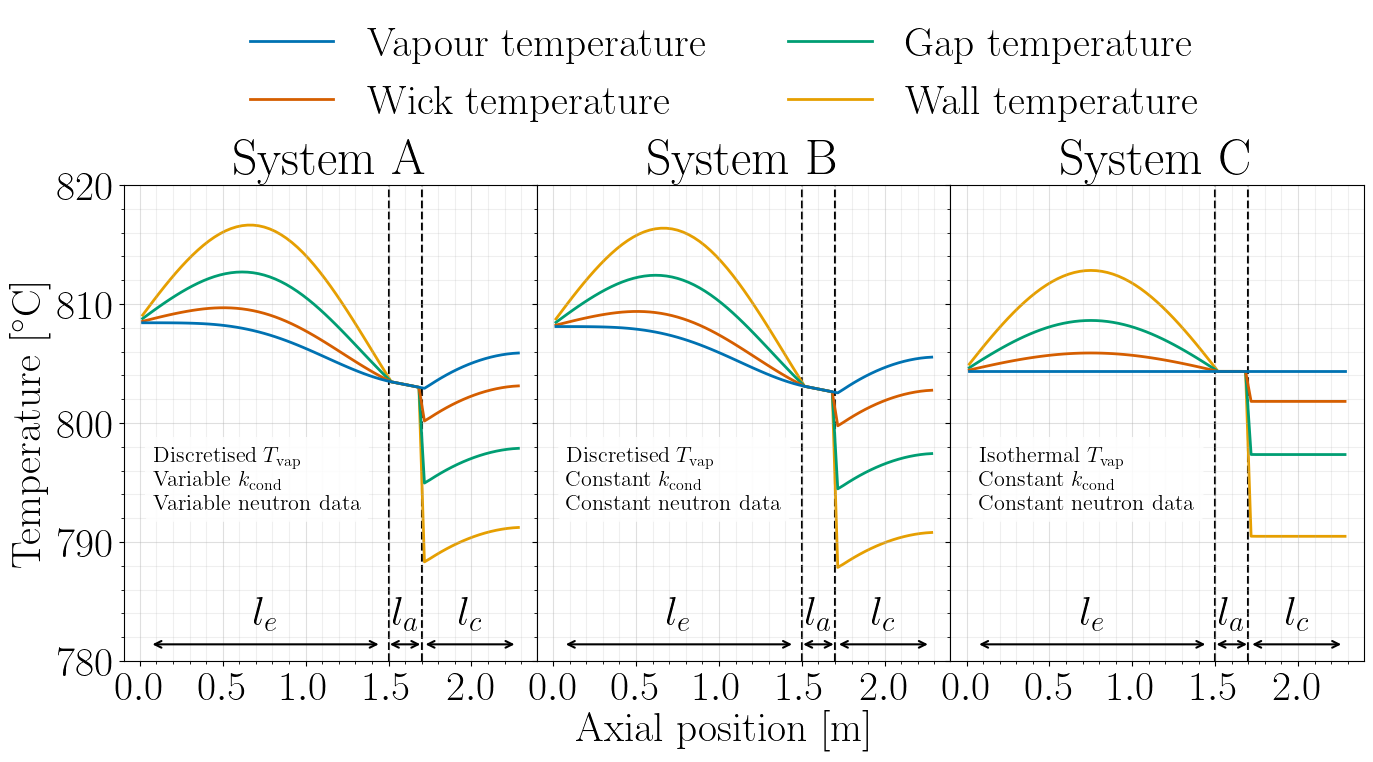

In [89]:
def to_celsius(T):
    return T - 273.15

def add_axial_region_arrows(
    ax,
    z_bounds,
    labels=("A", "B", "C"),
    y_arrow_frac=0.035,
    y_text_frac=0.06,
    shrink=0.04,
    arrow_lw=1.5,
    fontsize=30,
):
    """
    Add double-headed arrows and labels for axial heat-pipe regions.

    z_bounds should be (z_min, z_evap, z_adiabatic, z_max).
    y positions are given as fractions of the axis height.
    """
    y_arrow = ymin + y_arrow_frac * (ymax - ymin)
    y_text  = ymin + y_text_frac  * (ymax - ymin)

    for z0, z1, label in zip(z_bounds[:-1], z_bounds[1:], labels):
        dz = z1 - z0

        x0 = z0 + shrink * dz
        x1 = z1 - shrink * dz
        xc = 0.5 * (z0 + z1)

        ax.annotate(
            "",
            xy=(x1, y_arrow),
            xytext=(x0, y_arrow),
            arrowprops=dict(
                arrowstyle="<->",
                color="black",
                lw=arrow_lw,
                shrinkA=0,
                shrinkB=0,
                mutation_scale = 12
            ),
            zorder=10,
        )

        ax.text(
            xc,
            y_text,
            label,
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color="black",
            zorder=10,
        )


def add_model_textbox(ax, text, x=0.05, y=0.95, fontsize=16):
    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=fontsize,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=20,
    )

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(16, 7),
    sharey=True,
    gridspec_kw={"wspace": 0.0}
)

wick_slice = slice(0, cfg.HP.mesh.N_wick)
gap_slice = slice(cfg.HP.mesh.N_wick, cfg.HP.mesh.N_wick + cfg.HP.mesh.N_gap)
wall_slice = slice(cfg.HP.mesh.N_R - cfg.HP.mesh.N_wall, cfg.HP.mesh.N_R)

T_wick_avg = to_celsius(np.mean(T_solid_vap_full[:, wick_slice], axis=1))
T_gap_avg  = to_celsius(np.mean(T_solid_vap_full[:, gap_slice] , axis=1))
T_wall_avg = to_celsius(np.mean(T_solid_vap_full[:, wall_slice], axis=1))
T_vap_full = to_celsius(T_v_full)

T_wick_avg_vap = to_celsius(np.mean(T_solid_vap[:, wick_slice], axis=1))
T_gap_avg_vap  = to_celsius(np.mean(T_solid_vap[:, gap_slice] , axis=1))
T_wall_avg_vap = to_celsius(np.mean(T_solid_vap[:, wall_slice], axis=1))
T_vap          = to_celsius(T_v)

T_wick_avg_iso = to_celsius(np.mean(T_hp_iso[0][:, wick_slice], axis=1))
T_gap_avg_iso  = to_celsius(np.mean(T_hp_iso[0][:, gap_slice] , axis=1))
T_wall_avg_iso = to_celsius(np.mean(T_hp_iso[0][:, wall_slice], axis=1))
T_vap_iso      = to_celsius(np.full(z_hp.shape, T_hp_iso[-1]))

# Pick colours from a colormap for the different plotted quantities
cmap = plt.get_cmap("inferno")

# quantity_colors_cmap_cmap = {
#     "vapour": cmap(0.05),
#     "wick":   cmap(0.35),
#     "gap":    cmap(0.65),
#     "wall":   cmap(0.90),
# }

quantity_colors = {
    "vapour": colors["blue"],
    "wick": colors["red"],
    "gap": colors["green"],
    "wall": colors["orange"]
}

# Discretised vapour reactor, variable k, variable neutron data
ax1.plot(z_hp, T_vap_full, color=quantity_colors["vapour"], lw=2, linestyle="-", zorder=4)
ax1.plot(z_hp, T_wick_avg, color=quantity_colors["wick"],   lw=2, linestyle="-", zorder=3)
ax1.plot(z_hp, T_gap_avg,  color=quantity_colors["gap"],    lw=2, linestyle="-", zorder=2)
ax1.plot(z_hp, T_wall_avg, color=quantity_colors["wall"],   lw=2, linestyle="-", zorder=1)

# Discretised vapour reactor, constant k, constant neutron data
ax2.plot(z_hp, T_vap,          color=quantity_colors["vapour"], lw=2, linestyle="-", zorder=4)
ax2.plot(z_hp, T_wick_avg_vap, color=quantity_colors["wick"],   lw=2, linestyle="-", zorder=3)
ax2.plot(z_hp, T_gap_avg_vap,  color=quantity_colors["gap"],    lw=2, linestyle="-", zorder=2)
ax2.plot(z_hp, T_wall_avg_vap, color=quantity_colors["wall"],   lw=2, linestyle="-", zorder=1)

# Isothermal vapour reactor
ax3.plot(z_hp, T_vap_iso,                         color=quantity_colors["vapour"], lw=2, linestyle="-", zorder=4)
ax3.plot(z_hp, T_wick_avg_iso,                    color=quantity_colors["wick"],   lw=2, linestyle="-", zorder=3)
ax3.plot(z_hp, T_gap_avg_iso,                     color=quantity_colors["gap"],    lw=2, linestyle="-", zorder=2)
ax3.plot(z_hp, T_wall_avg_iso,                    color=quantity_colors["wall"],   lw=2, linestyle="-", zorder=1)

ymin, ymax = 780, 820
z_evap = cfg.HP.geometry.l_evap
z_adiabatic = cfg.HP.geometry.l_evap + cfg.HP.geometry.l_adiabatic

ax1.set_ylim((ymin, ymax))
ax2.set_ylim((ymin, ymax))
ax3.set_ylim((ymin, ymax))

ax1.set_title("System A")
ax2.set_title("System B")
ax3.set_title("System C")

add_model_textbox(
    ax1,
    "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
    y=0.45,
    x=0.07
)

add_model_textbox(
    ax2,
    "Discretised $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.45,
    x=0.07
)

add_model_textbox(
    ax3,
    "Isothermal $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.45,
    x=0.07
)

# dash_style = (5, (10, 3))

for ax in (ax1, ax2, ax3):
    ax.vlines(
        (z_evap, z_adiabatic),
        ymin,
        ymax,
        colors="black",
        linestyles="--",
        zorder=0,
    )

z_bounds = (
    np.min(z_hp),
    z_evap,
    z_adiabatic,
    np.max(z_hp),
)

for ax in (ax1, ax2, ax3):
    add_axial_region_arrows(
        ax,
        z_bounds,
        labels=(r"$l_e$", r"$l_a$", r"$l_c$"),
    )

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()

ax1.set_ylabel(r"Temperature [$\si{\celsius}$]", fontsize=30)
# ax1.set_xlabel("Axial position [m]")
# ax2.set_xlabel("Axial position [m]")
# ax3.set_xlabel("Axial position [m]")
fig.supxlabel(r"Axial position [$\si{\meter}$]", fontsize=30)

ax1.grid(which="major", alpha=0.4)
ax1.grid(which="minor", alpha=0.2)
ax2.grid(which="major", alpha=0.4)
ax2.grid(which="minor", alpha=0.2)
ax3.grid(which="major", alpha=0.4)
ax3.grid(which="minor", alpha=0.2)

ax1.xaxis.set_major_locator(MultipleLocator(0.5))
ax2.xaxis.set_major_locator(MultipleLocator(0.5))
ax3.xaxis.set_major_locator(MultipleLocator(0.5))

quantity_handles = [
    ax1.plot([], [], color=quantity_colors["vapour"], lw=2, linestyle="-",
             label="Vapour temperature")[0],
    ax1.plot([], [], color=quantity_colors["wick"], lw=2, linestyle="-",
             label="Wick temperature")[0],
    ax1.plot([], [], color=quantity_colors["gap"], lw=2, linestyle="-",
             label="Gap temperature")[0],
    ax1.plot([], [], color=quantity_colors["wall"], lw=2, linestyle="-",
             label="Wall temperature")[0],
]

fig.legend(
    handles=quantity_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
)

fig.subplots_adjust(
    top=0.82,
    bottom=0.14
)

# Hide labels on the right plot, but keep ticks for the grid
ax2.tick_params(axis="y", labelleft=False)
ax3.tick_params(axis="y", labelleft=False)

plt.savefig("./outputs/report_figures/reactor_results/axial_heatpipe.pdf", bbox_inches="tight")
plt.show()

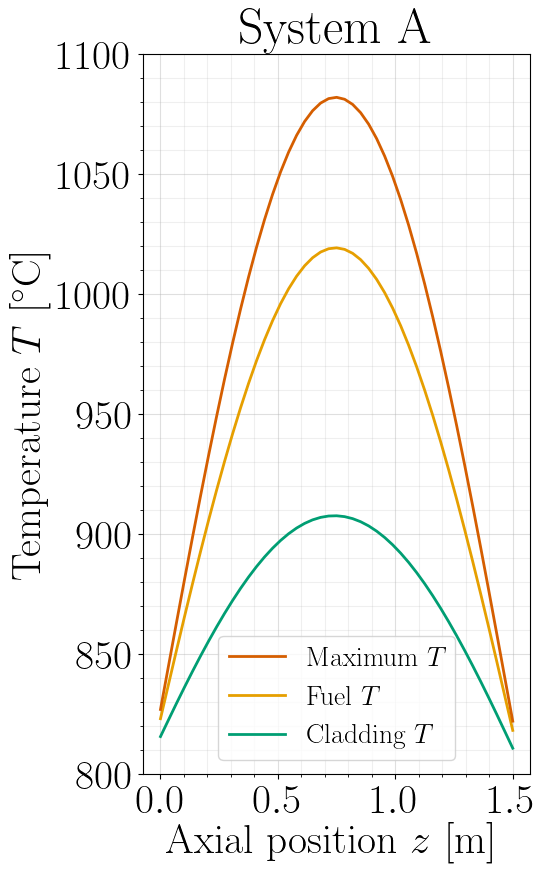

In [113]:
fig, ax1 = plt.subplots(
    1, 1,
    figsize=(5,10),
    sharey=True,
    gridspec_kw={"wspace": 0.0}
)

fuel_slice = slice(0, cfg.FP.mesh.N_fuel)
gap_slice  = slice(cfg.FP.mesh.N_fuel, cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap)
clad_slice = slice(cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap, cfg.FP.mesh.N_R)

# Average temperatures
T_fuel_avg_full = to_celsius(np.mean(T_FP_vap_full[:, fuel_slice], axis=1))
T_clad_avg_full = to_celsius(np.mean(T_FP_vap_full[:, clad_slice], axis=1))

T_fuel_avg = to_celsius(np.mean(T_FP_vap[:, fuel_slice], axis=1))
T_clad_avg = to_celsius(np.mean(T_FP_vap[:, clad_slice], axis=1))

T_fuel_avg_iso = to_celsius(np.mean(T_FP_iso[:, fuel_slice], axis=1))
T_clad_avg_iso = to_celsius(np.mean(T_FP_iso[:, clad_slice], axis=1))

# Radial slice indices corresponding to the global max/min temperatures
i_max_full = np.unravel_index(np.argmax(T_FP_vap_full), T_FP_vap_full.shape)[1]
i_min_full = np.unravel_index(np.argmin(T_FP_vap_full), T_FP_vap_full.shape)[1]

i_max = np.unravel_index(np.argmax(T_FP_vap), T_FP_vap.shape)[1]
i_min = np.unravel_index(np.argmin(T_FP_vap), T_FP_vap.shape)[1]

i_max_iso = np.unravel_index(np.argmax(T_FP_iso), T_FP_iso.shape)[1]
i_min_iso = np.unravel_index(np.argmin(T_FP_iso), T_FP_iso.shape)[1]

# Axial profiles of those radial slices
T_max_slice_full = to_celsius(T_FP_vap_full[:, i_max_full])
T_min_slice_full = to_celsius(T_FP_vap_full[:, i_min_full])

T_max_slice = to_celsius(T_FP_vap[:, i_max])
T_min_slice = to_celsius(T_FP_vap[:, i_min])

T_max_slice_iso = to_celsius(T_FP_iso[:, i_max_iso])
T_min_slice_iso = to_celsius(T_FP_iso[:, i_min_iso])

cmap = plt.get_cmap("magma")
quantity_colors = {
    "clad": colors["green"],
    "fuel": colors["orange"],
    "max":  colors["red"],
}

# Variable-k vapour reactor
ax1.plot(z_fp, T_max_slice_full, color=quantity_colors["max"],  lw=2, linestyle="-", zorder=4)
ax1.plot(z_fp, T_fuel_avg_full,  color=quantity_colors["fuel"], lw=2, linestyle="-", zorder=3)
ax1.plot(z_fp, T_clad_avg_full,  color=quantity_colors["clad"], lw=2, linestyle="-", zorder=2)

for ax in (ax1, ax2, ax3):
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.4)
    ax.grid(which="minor", alpha=0.2)
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(50))

ax1.set_ylabel(r"Temperature $T$ [\si{\celsius}]", fontsize=30)
fig.supxlabel(r"Axial position $z$ [$\si{\meter}$]", fontsize=30)

ax1.set_ylim((800, 1100))

ax1.set_title("System A")

ax1.xaxis.set_major_locator(MultipleLocator(0.5))

# add_model_textbox(
#     ax1,
#     "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
#     y=0.19,
#     x=0.25
# )

# add_model_textbox(
#     ax2,
#     "Discretised $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
#     y=0.19,
#     x=0.25
# )

# add_model_textbox(
#     ax3,
#     "Isothermal $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
#     y=0.19,
#     x=0.25
# )

color_handles = [
    Line2D([0], [0], color=quantity_colors["max"],  lw=2, linestyle="-", label=r"Maximum $T$"),
    Line2D([0], [0], color=quantity_colors["fuel"], lw=2, linestyle="-", label=r"Fuel $T$"),
    Line2D([0], [0], color=quantity_colors["clad"], lw=2, linestyle="-", label=r"Cladding $T$"),
]

ax1.legend(
    handles=color_handles,
    # loc="upper center",
    # bbox_to_anchor=(0.5, 1.10),
    ncol=1,
    # frameon=False,
    fontsize=20
)
fig.subplots_adjust(
    top=0.82,
    bottom=0.1
)

plt.savefig(r"./outputs/report_figures/reactor_results/axial_fuelpin.pdf", bbox_inches="tight")
plt.show()

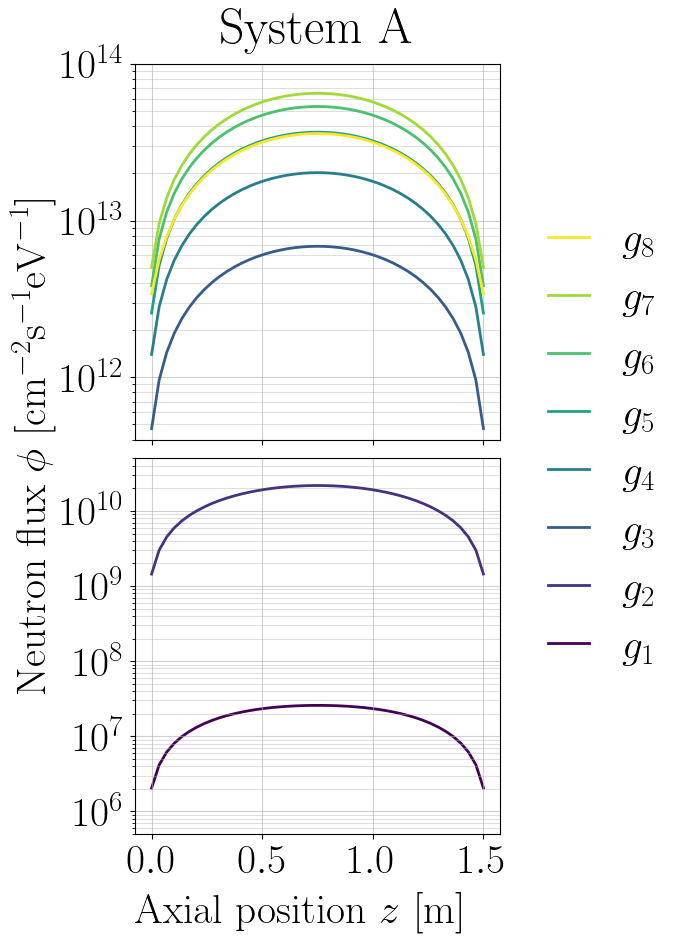

In [114]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, LogLocator, LogFormatterMathtext, NullFormatter
import numpy as np
import matplotlib.pyplot as plt

def add_free_text(ax, text, x=0.5, y=0.05, fontsize=22):
    ax.text(
        x, y,
        text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
        zorder=20,
    )

fig, axes = plt.subplots(
    2, 1,
    figsize=(5, 10),
    sharex=True,
    gridspec_kw={
        "hspace": 0.05,
    }
)

ax1, ax4 = axes

N_G = phi_n_g_vap_full.shape[1]

cmap = plt.get_cmap("viridis")
colors_cmap = cmap(np.linspace(0, 1, N_G)[::-1])

# Top row: all groups except the two lowest-flux ones
top_indices = range(0, max(N_G - 2, 0))

# Bottom row: the two lowest-flux groups
bottom_indices = range(max(N_G - 2, 0), N_G)

# Top plot
for i in top_indices:
    ax1.plot(
        z_fp,
        1e-4 * phi_n_g_vap_full[:, i],
        color=colors_cmap[i],
        lw=2,
        linestyle="-",
        zorder=8 - i,
    )

# Bottom plot
for i in bottom_indices:
    ax4.plot(
        z_fp,
        1e-4 * phi_n_g_vap_full[:, i],
        color=colors_cmap[i],
        lw=2,
        linestyle="-",
        zorder=8 - i,
    )

# Common formatting
for ax in axes:
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))

    ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100)
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.xaxis.set_major_locator(MultipleLocator(0.5))

    ax.grid(which="major", alpha=0.6)
    ax.grid(which="minor", alpha=0.4)

# Y-limits
ax1.set_ylim((4e15 * 1e-4, 1e18 * 1e-4))
ax4.set_ylim((5e9 * 1e-4, 5e14 * 1e-4))

# Title
ax1.set_title("System A", pad=14)

# Free text in upper plot
# add_free_text(
#     ax1,
#     r"$k_\text{eff} = $" + f"{k_vap_full:.4f}",
#     x=0.5,
#     y=0.05,
# )

# Axis labels
units = r"\si{\centi\meter^{-2}\second^{-1}\electronvolt^{-1}}"

fig.supylabel(rf"Neutron flux $\phi$ [{units}]", fontsize=30)
fig.supxlabel(r"Axial position $z$ [$\si{\meter}$]", fontsize=30, x=0.6)

# Hide x tick labels on top plot
ax1.tick_params(axis="x", labelbottom=False)

# Description box in bottom plot
# add_model_textbox(
#     ax4,
#     "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
#     y=0.255,
#     x=0.25,
# )

# Legend: all plotted groups
color_handles = [
    Line2D([0], [0], color=colors_cmap[i], lw=2, linestyle="-", label=rf"$g_{8 - i}$")
    for i in range(N_G)
]

fig.legend(
    handles=color_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
    handlelength=1,
)

fig.subplots_adjust(
    top=0.88,
    bottom=0.11,
    left=0.27,
    right=1,
)

plt.savefig(r"./outputs/report_figures/reactor_results/axial_neutron.pdf", bbox_inches="tight")
plt.show()

In [92]:
# ---------------------------------------------------------------------
# Collect systems
# ---------------------------------------------------------------------

systems = {
    "A": {
        "phi": phi_n_g_vap_full,
        "k": k_vap_full,
        "z": z_fp,
    },
    "B": {
        "phi": phi_n_g_vap,
        "k": k_vap,
        "z": z_fp,
    },
    "C": {
        "phi": phi_n_g_iso,
        "k": k_iso,
        "z": z_fp,
    },
}

# If your neutron-flux grid is actually z_hp rather than z_fp, change "z": z_fp to "z": z_hp above.

# ---------------------------------------------------------------------
# Choose group ranges
# ---------------------------------------------------------------------
# Assumption: g1 is highest energy and g8 is lowest energy.
# Adjust these if your group ordering is different.

fast_groups = [0, 1, 2, 3]       # g1--g4
thermal_groups = [6, 7]          # g7--g8

# ---------------------------------------------------------------------
# Unit conversion
# ---------------------------------------------------------------------
# Your stored phi is in m^-2 s^-1 eV^-1.
# For plotting/table values in cm^-2 s^-1 eV^-1, divide by 1e4.

USE_CM_UNITS = True

phi_factor = 1e-4 if USE_CM_UNITS else 1.0
flux_unit = r"\si{\centi\meter^{-2}\second^{-1}\electronvolt^{-1}}" if USE_CM_UNITS else r"\si{\meter^{-2}\second^{-1}\electronvolt^{-1}}"

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def sci_latex(x, sig=4):
    if x == 0:
        return "0"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / 10**exponent

    return rf"{mantissa:.{sig-1}f}\times 10^{{{exponent}}}"


def compute_flux_quantities(phi, z):
    phi = np.asarray(phi) * phi_factor
    z = np.asarray(z)

    phi_tot_z = np.sum(phi, axis=1)

    Phi_g = np.trapezoid(phi, z, axis=0)
    Phi_tot = np.sum(Phi_g)

    Phi_fast = np.sum(Phi_g[fast_groups])
    Phi_thermal = np.sum(Phi_g[thermal_groups])

    f_g = Phi_g / Phi_tot

    return {
        "Phi_g": Phi_g,
        "Phi_tot": Phi_tot,
        "Phi_fast": Phi_fast,
        "Phi_thermal": Phi_thermal,
        "fast_thermal_ratio": Phi_fast / Phi_thermal,
        "max_phi_tot": np.max(phi_tot_z),
        "avg_phi_tot": Phi_tot / (z[-1] - z[0]),
        "f_g": f_g,
    }


results = {}

for name, data in systems.items():
    results[name] = compute_flux_quantities(data["phi"], data["z"])
    results[name]["k"] = data["k"]

# ---------------------------------------------------------------------
# Compact comparison table
# ---------------------------------------------------------------------

rows = [
    (r"$k_\text{eff}$", "k", "{:.4f}"),
    (r"$\int_0^L \sum_g \phi_g\, dz$", "Phi_tot", sci_latex),
    (r"$\max_z \sum_g \phi_g$", "max_phi_tot", sci_latex),
    (r"$\langle \sum_g \phi_g \rangle_z$", "avg_phi_tot", sci_latex),
    (r"$\Phi_\text{fast}/\Phi_\text{thermal}$", "fast_thermal_ratio", "{:.4f}"),
]

print(r"\begin{tabular}{lccc}")
print(r"\hline")
print(r"\textbf{Quantity} & \textbf{A} & \textbf{B} & \textbf{C} \\")
print(r"\hline")

for label, key, fmt in rows:
    values = []
    for name in ["A", "B", "C"]:
        value = results[name][key]

        if isinstance(fmt, str):
            values.append(fmt.format(value))
        else:
            values.append(rf"${fmt(value)}$")

    print(label + " & " + " & ".join(values) + r" \\")

print(r"\hline")
print(r"\end{tabular}")

\begin{tabular}{lccc}
\hline
\textbf{Quantity} & \textbf{A} & \textbf{B} & \textbf{C} \\
\hline
$k_\text{eff}$ & 1.1040 & 1.1216 & 1.1216 \\
$\int_0^L \sum_g \phi_g\, dz$ & $2.192\times 10^{14}$ & $2.161\times 10^{14}$ & $2.161\times 10^{14}$ \\
$\max_z \sum_g \phi_g$ & $2.184\times 10^{14}$ & $2.158\times 10^{14}$ & $2.158\times 10^{14}$ \\
$\langle \sum_g \phi_g \rangle_z$ & $1.461\times 10^{14}$ & $1.441\times 10^{14}$ & $1.441\times 10^{14}$ \\
$\Phi_\text{fast}/\Phi_\text{thermal}$ & 8841.6710 & 6833.3733 & 6833.3733 \\
\hline
\end{tabular}
